# 04 — Report: pretrained universal MLIPs for harmonic phonons

This notebook analyzes the results produced by the three production notebooks:

- **MACE-MP-0**
- **CHGNet**
- **M3GNet MP-2021.2.8-EFS**

against the **PBE Alexandria phonon benchmark** used by Loew *et al.* in  
*Universal machine learning interatomic potentials are ready for phonons*,  
npj Computational Materials **11**, 178 (2025).

The MLIP calculations are **not recomputed here**. The notebook reads the JSON files
already stored in `data/results/` and reconstructs only the lightweight DFT reference
quantities directly from the Alexandria Phonopy files.

## Scope

This is a deliberately reduced reproduction of the original benchmark on eight simple
crystals. The report focuses on relaxed-cell volume, maximum phonon frequency
\(\omega_{\max}\), dynamical stability, phonon dispersions, vibrational entropy
\(S\), Helmholtz free energy \(F\), and heat capacity \(C_V\) at 300 K.

The original paper also benchmarks phonon DOS and sound velocity. Those quantities are
outside this reduced scope and are therefore **not claimed to be reproduced**.

PBE is the main DFT reference. PBEsol is used only as a secondary DFT-level baseline.
NAC is disabled consistently in the DFT reference because the three MLIPs do not provide
Born effective charges.

## 1. Setup and load the stored MLIP results

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_here = Path.cwd().resolve()
ROOT = next(
    (
        p for p in [_here, *_here.parents]
        if (p / "src").is_dir() and (p / "data" / "results").is_dir()
    ),
    None,
)

if ROOT is None:
    raise RuntimeError(
        "Could not locate the project root. Run this notebook from inside "
        "the mlip-phonon-benchmark repository."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import RESULTS, FIGURES
import src.materials as M
from src.io_utils import load_result
from src.reference import load_reference
from src.phonons import (
    ph_to_ase,
    max_frequency,
    has_imaginary,
    thermal_properties,
    at_temperature,
    make_band_path,
    band_structure,
)

FIGURES.mkdir(parents=True, exist_ok=True)

MODELS = ("mace", "chgnet", "m3gnet")
MODEL_LABELS = {
    "mace": "MACE-MP-0",
    "chgnet": "CHGNet",
    "m3gnet": "M3GNet",
}
MATERIALS = list(M.MATERIALS)

THZ_TO_K = 1.0 / 0.0208366191

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Project root:", ROOT)
print("Materials:", MATERIALS)

Matplotlib is building the font cache; this may take a moment.


Project root: C:\Users\an.doronzo\Desktop\mmm\mlip-phonon-benchmark
Materials: ['Si', 'SiC', 'AlP', 'ZnS', 'MgO', 'NaCl', 'AlN', 'GaN']


In [2]:
results = {
    model: {
        material: load_result(model, material)
        for material in MATERIALS
    }
    for model in MODELS
}

run_metadata = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[model],
            "model_version": results[model][MATERIALS[0]]["model_version"],
            "dtype": results[model][MATERIALS[0]]["dtype"],
            "displacement_A": results[model][MATERIALS[0]]["displacement"],
            "fmax_eV_A": results[model][MATERIALS[0]]["fmax"],
        }
        for model in MODELS
    ]
)

display(run_metadata)

,model,model_version,dtype,displacement_A,fmax_eV_A
0,MACE-MP-0,MACE-MP-0 medium (2023-12-03-mace-128-L1_epoch...,float64,0.01,0.005
1,CHGNet,CHGNet default pretrained model v0.3.0; chgnet...,float32,0.01,0.005
2,M3GNet,MP-2021.2.8-EFS; m3gnet=0.2.4; tensorflow=2.15...,float32,0.01,0.005


MACE uses float64, whereas CHGNet and legacy M3GNet use float32. This is a model-specific
implementation detail. The physical protocol remains common: PBE starting structures,
PBE reference supercell/primitive matrices, 0.01 Å displacements, and
\(f_{\max}=0.005\) eV/Å.

## 2. Reconstruct the PBE and PBEsol DFT references

The Alexandria files already contain DFT force constants, so reconstructing reference
observables is inexpensive compared with running the MLIPs.

PBE is the benchmark reference. PBEsol is retained as a secondary baseline measuring
the effect of changing the DFT exchange-correlation functional.

In [3]:
def build_reference_record(material, functional="pbe", with_bands=False):
    meta = M.MATERIALS[material]

    ph = load_reference(
        meta["mp_id"],
        functional=functional,
        use_nac=False,
    )

    tp = thermal_properties(ph)
    atoms = ph_to_ase(ph.unitcell)

    record = {
        "ph": ph,
        "omega_max_THz": max_frequency(ph),
        "has_imaginary": has_imaginary(ph),
        "thermal": tp,
        "thermal_300K": at_temperature(tp, 300.0),
        "volume": float(atoms.get_volume()),
        "n_atoms_unitcell": len(atoms),
        "lattice": atoms.cell.cellpar().tolist(),
        "supercell_matrix": np.asarray(ph.supercell_matrix, dtype=int),
        "primitive_matrix": np.asarray(ph.primitive_matrix, dtype=float),
    }

    if with_bands:
        path = make_band_path(ph, npoints=101)
        record["band_path"] = path
        record["bands"] = band_structure(ph, path)

    return record


pbe = {
    material: build_reference_record(material, "pbe", with_bands=True)
    for material in MATERIALS
}

pbesol = {
    material: build_reference_record(material, "pbesol", with_bands=False)
    for material in MATERIALS
}

print("Loaded PBE and PBEsol references for", len(MATERIALS), "materials.")

Loaded PBE and PBEsol references for 8 materials.


## 3. Final protocol-integrity check

Before analyzing the results, verify that every stored JSON is compatible with the final
methodology. A stale file produced with an older protocol should stop the report instead
of silently entering the statistics.

In [4]:
def assert_segment_arrays_equal(a_segments, b_segments, atol=1e-10):
    assert len(a_segments) == len(b_segments)

    for a, b in zip(a_segments, b_segments):
        assert np.allclose(
            np.asarray(a),
            np.asarray(b),
            atol=atol,
            rtol=0,
        )


for material in MATERIALS:
    for model in MODELS:
        r = results[model][material]
        ref = pbe[material]

        assert np.isclose(r["displacement"], 0.01)
        assert np.isclose(r["fmax"], 0.005)

        assert np.array_equal(
            np.asarray(r["supercell_matrix"], dtype=int),
            ref["supercell_matrix"],
        )

        assert np.allclose(
            np.asarray(r["primitive_matrix"], dtype=float),
            ref["primitive_matrix"],
            atol=1e-12,
            rtol=0,
        )

        assert_segment_arrays_equal(
            r["bands"]["qpoints"],
            ref["bands"]["qpoints"],
        )

        assert_segment_arrays_equal(
            r["bands"]["distances"],
            ref["bands"]["distances"],
        )

print("OK: all 24 MLIP results are consistent with the final PBE-based protocol.")

OK: all 24 MLIP results are consistent with the final PBE-based protocol.


In [5]:
dataset_summary = pd.DataFrame(
    [
        {
            "material": material,
            "structure": M.MATERIALS[material]["structure"],
            "PBE supercell": pbe[material]["supercell_matrix"].tolist(),
            "PBE unit-cell atoms": pbe[material]["n_atoms_unitcell"],
            "displaced-supercell atoms": results["mace"][material]["n_atoms_supercell"],
        }
        for material in MATERIALS
    ]
)

display(dataset_summary)

,material,structure,PBE supercell,PBE unit-cell atoms,displaced-supercell atoms
0,Si,diamond,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
1,SiC,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
2,AlP,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
3,ZnS,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
4,MgO,rocksalt,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
5,NaCl,rocksalt,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
6,AlN,wurtzite,"[[4, 0, 0], [0, 4, 0], [0, 0, 2]]",4,128
7,GaN,wurtzite,"[[4, 0, 0], [0, 4, 0], [0, 0, 2]]",4,128


## 4. Geometry relaxation: volume error

Phonons are calculated around a relaxed minimum of each MLIP potential-energy surface.
Before looking at second derivatives, it is useful to quantify how far the relaxed MLIP
geometry moves from the PBE reference.

Volumes are reported **per atom** so that different cell conventions can be compared.

In [6]:
volume_rows = []

for material in MATERIALS:
    pbe_vpa = pbe[material]["volume"] / pbe[material]["n_atoms_unitcell"]
    pbesol_vpa = (
        pbesol[material]["volume"] / pbesol[material]["n_atoms_unitcell"]
    )

    row = {
        "material": material,
        "PBE": pbe_vpa,
        "PBEsol": pbesol_vpa,
        "PBEsol - PBE": pbesol_vpa - pbe_vpa,
    }

    for model in MODELS:
        label = MODEL_LABELS[model]
        mlip_vpa = (
            results[model][material]["volume"]
            / pbe[material]["n_atoms_unitcell"]
        )
        row[label] = mlip_vpa
        row[f"{label} error"] = mlip_vpa - pbe_vpa

    volume_rows.append(row)

volume_table = pd.DataFrame(volume_rows).set_index("material")
display(volume_table.round(4))

,PBE,PBEsol,PBEsol - PBE,MACE-MP-0,MACE-MP-0 error,CHGNet,CHGNet error,M3GNet,M3GNet error
material,,,,,,,,,
Si,20.4272,20.0635,-0.3638,20.2903,-0.1369,20.3601,-0.0671,20.2254,-0.2019
SiC,10.4990,10.3537,-0.1453,10.4778,-0.0212,10.4910,-0.0081,10.4866,-0.0124
AlP,20.8500,20.4617,-0.3883,20.9681,0.1181,20.9369,0.0868,20.8472,-0.0028
ZnS,20.1426,19.1965,-0.9461,20.2030,0.0604,20.1957,0.0531,20.2630,0.1204
MgO,9.6361,9.3756,-0.2604,9.6317,-0.0044,9.6361,0.0000,9.6361,0.0000
NaCl,23.0339,21.9468,-1.0871,22.9682,-0.0656,23.0673,0.0334,23.0758,0.0419
AlN,10.6304,10.4600,-0.1703,10.5974,-0.0330,10.6245,-0.0059,10.6117,-0.0187
GaN,11.7623,11.3523,-0.4101,11.6523,-0.1100,11.6739,-0.0884,11.7698,0.0074


In [7]:
volume_mae_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]
    errors = volume_table[f"{label} error"].to_numpy()

    volume_mae_rows.append(
        {
            "model": label,
            "MAE volume [A^3/atom]": np.mean(np.abs(errors)),
            "mean signed error [A^3/atom]": np.mean(errors),
        }
    )

pbesol_errors = volume_table["PBEsol - PBE"].to_numpy()

volume_mae_rows.append(
    {
        "model": "PBEsol",
        "MAE volume [A^3/atom]": np.mean(np.abs(pbesol_errors)),
        "mean signed error [A^3/atom]": np.mean(pbesol_errors),
    }
)

volume_mae = pd.DataFrame(volume_mae_rows).set_index("model")
display(volume_mae.round(4))

,MAE volume [A^3/atom],mean signed error [A^3/atom]
model,,
MACE-MP-0,0.0687,-0.0241
CHGNet,0.0429,0.0005
M3GNet,0.0507,-0.0082
PBEsol,0.4714,-0.4714


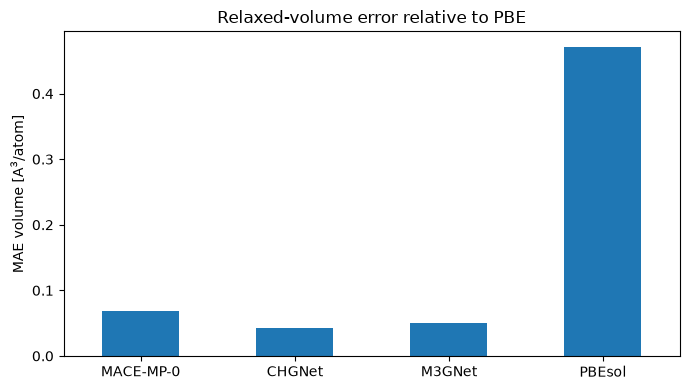

In [8]:
ax = volume_mae["MAE volume [A^3/atom]"].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_ylabel("MAE volume [A$^3$/atom]")
ax.set_xlabel("")
ax.set_title("Relaxed-volume error relative to PBE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "volume_mae.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Maximum phonon frequency — main benchmark metric

The maximum phonon frequency probes the stiffness of the potential around equilibrium.
Following Loew *et al.*, \(\omega_{\max}\) is evaluated only at q-points
**commensurate with the supercell matrix**, not on the interpolated 20×20×20 mesh used
for thermodynamic properties.

The paper reports this error in Kelvin. Here 1 THz corresponds to approximately
47.99 K through \(h\nu/k_B\).

In [9]:
omega_rows = []

for material in MATERIALS:
    ref = pbe[material]["omega_max_THz"]

    row = {
        "material": material,
        "PBE [THz]": ref,
        "PBEsol [THz]": pbesol[material]["omega_max_THz"],
    }

    for model in MODELS:
        label = MODEL_LABELS[model]
        pred = results[model][material]["omega_max_THz"]
        err = pred - ref

        row[f"{label} [THz]"] = pred
        row[f"{label} error [THz]"] = err
        row[f"{label} abs. error [K]"] = abs(err) * THZ_TO_K

    omega_rows.append(row)

omega_table = pd.DataFrame(omega_rows).set_index("material")

display(
    omega_table[
        [
            "PBE [THz]",
            "PBEsol [THz]",
            "MACE-MP-0 [THz]",
            "CHGNet [THz]",
            "M3GNet [THz]",
        ]
    ].round(3)
)

,PBE [THz],PBEsol [THz],MACE-MP-0 [THz],CHGNet [THz],M3GNet [THz]
material,,,,,
Si,15.107,15.287,11.190,13.104,8.469
SiC,24.418,24.729,21.876,17.967,19.925
AlP,12.792,13.020,10.509,9.363,8.966
ZnS,9.634,10.076,8.620,6.539,8.184
MgO,16.459,16.694,15.023,15.951,16.113
NaCl,6.254,6.499,5.515,4.196,5.549
AlN,25.039,25.409,19.986,22.536,22.706
GaN,20.412,21.022,18.616,19.103,18.322


In [10]:
omega_stats_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]
    err_thz = omega_table[f"{label} error [THz]"].to_numpy()

    omega_stats_rows.append(
        {
            "model": label,
            "MAE [THz]": np.mean(np.abs(err_thz)),
            "MAE [K]": np.mean(np.abs(err_thz)) * THZ_TO_K,
            "mean signed error [THz]": np.mean(err_thz),
            "mean signed error [K]": np.mean(err_thz) * THZ_TO_K,
            "RMSE [K]": np.sqrt(np.mean(err_thz**2)) * THZ_TO_K,
        }
    )

omega_stats = pd.DataFrame(omega_stats_rows).set_index("model")
display(omega_stats.round(2))

,MAE [THz],MAE [K],mean signed error [THz],mean signed error [K],RMSE [K]
model,,,,,
MACE-MP-0,2.35,112.66,-2.35,-112.66,130.79
CHGNet,2.67,128.11,-2.67,-128.11,151.23
M3GNet,2.74,131.27,-2.74,-131.27,162.24


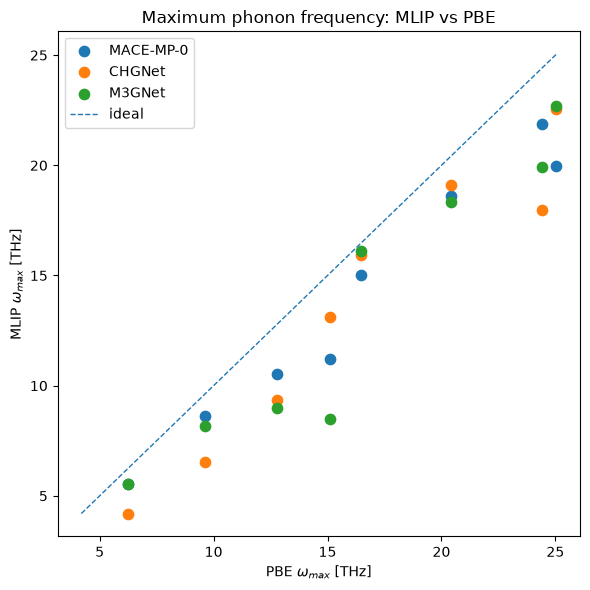

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

pbe_omega = np.array(
    [pbe[m]["omega_max_THz"] for m in MATERIALS],
    dtype=float,
)

all_pred = []

for model in MODELS:
    pred = np.array(
        [results[model][m]["omega_max_THz"] for m in MATERIALS],
        dtype=float,
    )
    all_pred.extend(pred.tolist())

    ax.scatter(
        pbe_omega,
        pred,
        label=MODEL_LABELS[model],
        s=55,
    )

lo = min(pbe_omega.min(), min(all_pred))
hi = max(pbe_omega.max(), max(all_pred))

ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, label="ideal")
ax.set_xlabel("PBE $\\omega_{max}$ [THz]")
ax.set_ylabel("MLIP $\\omega_{max}$ [THz]")
ax.set_title("Maximum phonon frequency: MLIP vs PBE")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "omega_max_pred_vs_pbe.png", dpi=180, bbox_inches="tight")
plt.show()

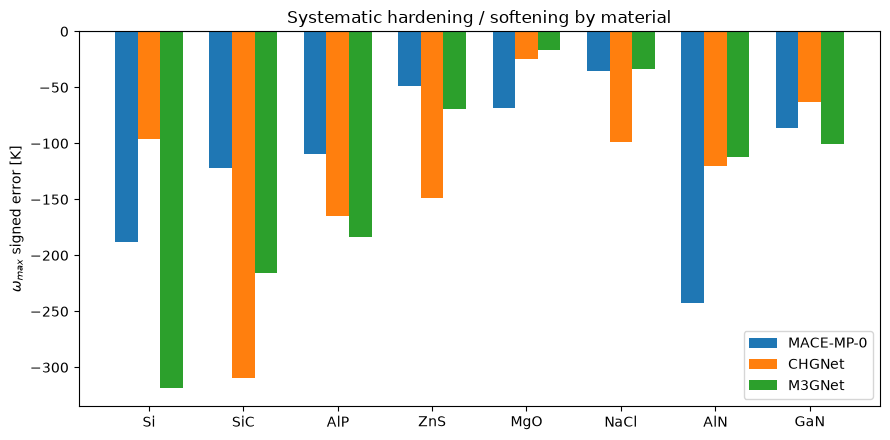

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(MATERIALS))
width = 0.24

for i, model in enumerate(MODELS):
    label = MODEL_LABELS[model]
    errors_k = (
        omega_table[f"{label} error [THz]"].to_numpy()
        * THZ_TO_K
    )

    ax.bar(
        x + (i - 1) * width,
        errors_k,
        width=width,
        label=label,
    )

ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MATERIALS)
ax.set_ylabel("$\\omega_{max}$ signed error [K]")
ax.set_title("Systematic hardening / softening by material")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "omega_max_signed_errors.png", dpi=180, bbox_inches="tight")
plt.show()

A negative signed error corresponds to a softer predicted spectrum than PBE; a positive
error corresponds to hardening. Because this subset contains only eight deliberately
simple crystals, its MAE must not be interpreted as a replacement for the statistics of
the approximately 10,000-material benchmark.

## 6. Comparison with the published full benchmark

The following values are **external reference values from Table 2 of Loew et al.**
They are not calculated from this repository.

| Model | MAE(omega_max) [K] | MAE(S) [J/K/mol] | MAE(F) [kJ/mol] | MAE(Cv) [J/K/mol] |
|---|---:|---:|---:|---:|
| MACE-MP-0 | 61 | 60 | 24 | 13 |
| CHGNet | 89 | 114 | 45 | 21 |
| M3GNet | 98 | 150 | 56 | 22 |
| PBEsol vs PBE | 33 | 25 | 10 | 5 |

These full-benchmark values provide **context**, not an expected numerical target for
an eight-material subset.

In [13]:
PAPER_MAE = pd.DataFrame(
    {
        "omega_max [K]": {
            "MACE-MP-0": 61.0,
            "CHGNet": 89.0,
            "M3GNet": 98.0,
            "PBEsol": 33.0,
        },
        "S [J/K/mol]": {
            "MACE-MP-0": 60.0,
            "CHGNet": 114.0,
            "M3GNet": 150.0,
            "PBEsol": 25.0,
        },
        "F [kJ/mol]": {
            "MACE-MP-0": 24.0,
            "CHGNet": 45.0,
            "M3GNet": 56.0,
            "PBEsol": 10.0,
        },
        "C_v [J/K/mol]": {
            "MACE-MP-0": 13.0,
            "CHGNet": 21.0,
            "M3GNet": 22.0,
            "PBEsol": 5.0,
        },
    }
)

omega_paper_comparison = pd.DataFrame(
    {
        "this 8-material subset [K]": omega_stats["MAE [K]"],
        "Loew et al. full benchmark [K]": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "omega_max [K]",
        ],
    }
)

display(omega_paper_comparison.round(1))

,this 8-material subset [K],Loew et al. full benchmark [K]
MACE-MP-0,112.7,61.0
CHGNet,128.1,89.0
M3GNet,131.3,98.0


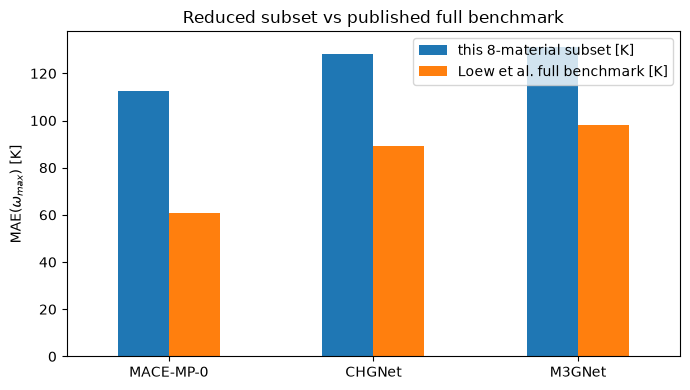

In [14]:
ax = omega_paper_comparison.plot(kind="bar", figsize=(7, 4))

ax.set_ylabel("MAE($\\omega_{max}$) [K]")
ax.set_xlabel("")
ax.set_title("Reduced subset vs published full benchmark")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "omega_max_vs_paper.png", dpi=180, bbox_inches="tight")
plt.show()

In [15]:
our_ranking = list(omega_stats["MAE [K]"].sort_values().index)

paper_ranking = list(
    PAPER_MAE.loc[
        ["MACE-MP-0", "CHGNet", "M3GNet"],
        "omega_max [K]",
    ].sort_values().index
)

ranking_text = (
    "The ranking on this subset is **"
    + " < ".join(our_ranking)
    + "** (lower MAE is better). "
    + "The published full-benchmark ranking among these models is **"
    + " < ".join(paper_ranking)
    + "**."
)

if our_ranking == paper_ranking:
    ranking_text += (
        " The reduced subset reproduces the same ordering, although not "
        "necessarily the same MAE values."
    )
else:
    ranking_text += (
        " The ordering differs on this small subset, which is plausible because "
        "eight simple crystals are not statistically representative of the full dataset."
    )

display(Markdown(ranking_text))

The ranking on this subset is **MACE-MP-0 < CHGNet < M3GNet** (lower MAE is better). The published full-benchmark ranking among these models is **MACE-MP-0 < CHGNet < M3GNet**. The reduced subset reproduces the same ordering, although not necessarily the same MAE values.

## 7. Dynamical stability

A structure is classified as dynamically stable when no imaginary phonon frequencies
are present at the q-points commensurate with the supercell, except for the three
acoustic modes at Gamma where the benchmark allows a small negative tolerance down to
-50 K.

With only eight hand-picked crystals, this is primarily a consistency check rather than
a reproduction of the paper's confusion-matrix statistics.

In [16]:
stability_rows = []

for material in MATERIALS:
    row = {
        "material": material,
        "PBE stable": not pbe[material]["has_imaginary"],
        "PBEsol stable": not pbesol[material]["has_imaginary"],
    }

    for model in MODELS:
        row[f"{MODEL_LABELS[model]} stable"] = (
            not results[model][material]["has_imaginary"]
        )

    stability_rows.append(row)

stability_table = pd.DataFrame(stability_rows).set_index("material")
display(stability_table)

,PBE stable,PBEsol stable,MACE-MP-0 stable,CHGNet stable,M3GNet stable
material,,,,,
Si,True,True,True,True,True
SiC,True,True,True,True,True
AlP,True,True,True,True,True
ZnS,True,True,True,True,True
MgO,True,True,True,True,True
NaCl,True,True,True,True,True
AlN,True,True,True,True,True
GaN,True,True,True,True,True


In [17]:
stability_summary_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]

    ref_stable = stability_table["PBE stable"].to_numpy(dtype=bool)
    pred_stable = stability_table[f"{label} stable"].to_numpy(dtype=bool)

    stability_summary_rows.append(
        {
            "model": label,
            "agreement": int(np.sum(ref_stable == pred_stable)),
            "out of": len(MATERIALS),
            "false unstable": int(np.sum(ref_stable & ~pred_stable)),
            "false stable": int(np.sum(~ref_stable & pred_stable)),
        }
    )

stability_summary = pd.DataFrame(stability_summary_rows).set_index("model")
display(stability_summary)

,agreement,out of,false unstable,false stable
model,,,,
MACE-MP-0,8,8,0,0
CHGNet,8,8,0,0
M3GNet,8,8,0,0


## 8. Phonon dispersions

A scalar such as omega_max cannot show where in reciprocal space a model deviates from
DFT. Dispersion curves provide a branch-resolved qualitative view.

Three crystal families are shown:

- **Si** — diamond;
- **SiC** — zincblende;
- **AlN** — wurtzite.

The path and distance axis are generated from the PBE reference and are exactly the same
for PBE and all three MLIPs.

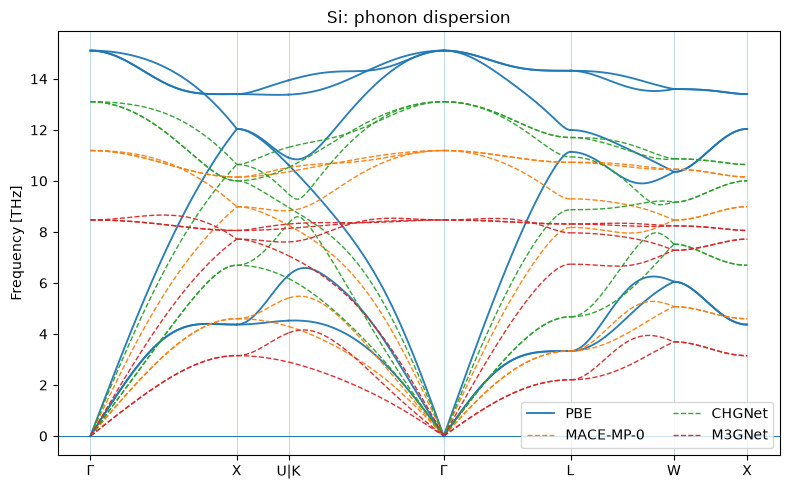

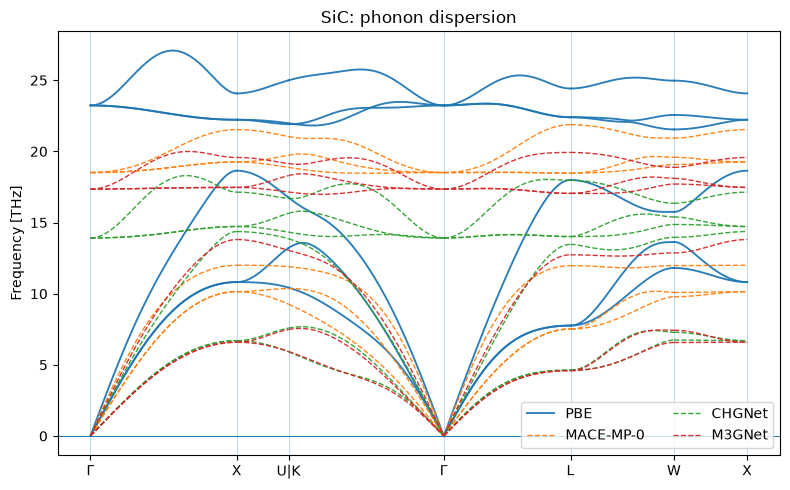

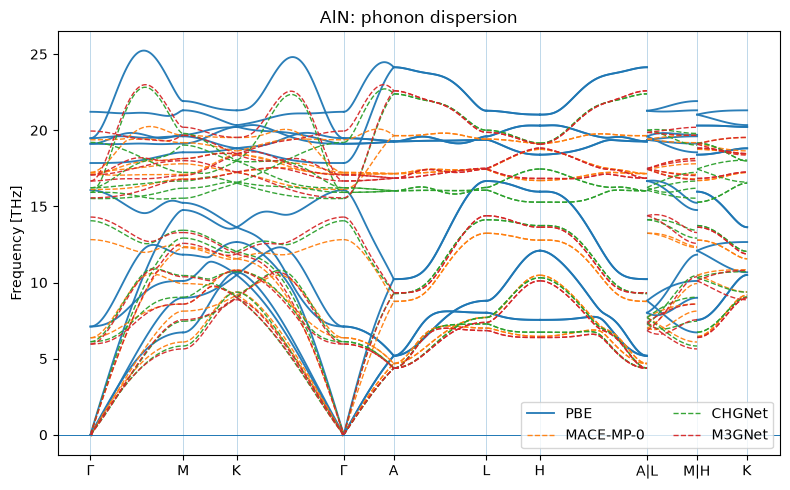

In [18]:
DISPERSION_MATERIALS = ["Si", "SiC", "AlN"]


def band_ticks(bands):
    distances = bands["distances"]
    labels = list(bands.get("labels") or [])
    connections = list(bands.get("path_connections") or [])

    if not labels:
        return [], []

    ticks = []
    tick_labels = []
    label_idx = 0

    def add_tick(x, label):
        if ticks and np.isclose(x, ticks[-1], atol=1e-10):
            if tick_labels[-1] != label:
                tick_labels[-1] += "|" + label
        else:
            ticks.append(x)
            tick_labels.append(label)

    for i, dist in enumerate(distances):
        dist = np.asarray(dist, dtype=float)

        # First segment, or first segment after a disconnected path.
        if i == 0 or not connections[i - 1]:
            add_tick(
                float(dist[0]),
                labels[label_idx],
            )
            label_idx += 1

        # End of current segment.
        add_tick(
            float(dist[-1]),
            labels[label_idx],
        )
        label_idx += 1

    assert label_idx == len(labels), (
        f"Used {label_idx} labels, but {len(labels)} were provided."
    )

    return ticks, tick_labels


def plot_dispersion(material):
    sources = [
        ("PBE", pbe[material]["bands"]),
        *[
            (MODEL_LABELS[model], results[model][material]["bands"])
            for model in MODELS
        ],
    ]

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for source_idx, (label, bands) in enumerate(sources):
        color = default_colors[source_idx % len(default_colors)]

        for seg_idx, (dist, freq) in enumerate(
            zip(bands["distances"], bands["frequencies"])
        ):
            dist = np.asarray(dist, dtype=float)
            freq = np.asarray(freq, dtype=float)

            for branch_idx in range(freq.shape[1]):
                ax.plot(
                    dist,
                    freq[:, branch_idx],
                    color=color,
                    linewidth=1.35 if label == "PBE" else 1.0,
                    linestyle="-" if label == "PBE" else "--",
                    alpha=0.95,
                    label=(
                        label
                        if seg_idx == 0 and branch_idx == 0
                        else None
                    ),
                )

    ticks, labels = band_ticks(pbe[material]["bands"])

    for x_tick in ticks:
        ax.axvline(x_tick, linewidth=0.5, alpha=0.4)

    ax.axhline(0, linewidth=0.7)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Frequency [THz]")
    ax.set_title(f"{material}: phonon dispersion")
    ax.legend(ncol=2)

    plt.tight_layout()
    plt.savefig(
        FIGURES / f"dispersion_{material}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


for material in DISPERSION_MATERIALS:
    plot_dispersion(material)

## 9. Thermodynamic properties at 300 K

Thermodynamic quantities are evaluated on the Gamma-centered 20×20×20 mesh used in the
production calculations:

- vibrational entropy \(S\) [J/K/mol];
- Helmholtz free energy \(F\) [kJ/mol];
- constant-volume heat capacity \(C_V\) [J/K/mol].

In [19]:
THERMAL_METRICS = {
    "S": ("S [J/K/mol]", "J/K/mol"),
    "F": ("F [kJ/mol]", "kJ/mol"),
    "C_v": ("C_v [J/K/mol]", "J/K/mol"),
}

thermal_rows = []

for material in MATERIALS:
    row = {"material": material}

    for metric, (pretty, _) in THERMAL_METRICS.items():
        row[f"PBE {pretty}"] = pbe[material]["thermal_300K"][metric]
        row[f"PBEsol {pretty}"] = pbesol[material]["thermal_300K"][metric]

        for model in MODELS:
            row[f"{MODEL_LABELS[model]} {pretty}"] = (
                results[model][material]["thermal_300K"][metric]
            )

    thermal_rows.append(row)

thermal_table = pd.DataFrame(thermal_rows).set_index("material")
display(thermal_table.round(3))

,PBE S [J/K/mol],PBEsol S [J/K/mol],MACE-MP-0 S [J/K/mol],CHGNet S [J/K/mol],M3GNet S [J/K/mol],PBE F [kJ/mol],PBEsol F [kJ/mol],MACE-MP-0 F [kJ/mol],CHGNet F [kJ/mol],M3GNet F [kJ/mol],PBE C_v [J/K/mol],PBEsol C_v [J/K/mol],MACE-MP-0 C_v [J/K/mol],CHGNet C_v [J/K/mol],M3GNet C_v [J/K/mol]
material,,,,,,,,,,,,,,,
Si,39.332,39.692,48.437,40.758,60.237,6.519,6.488,2.505,5.366,-1.777,40.065,39.894,43.501,41.894,45.673
SiC,17.378,17.248,23.095,31.866,29.856,19.073,19.325,14.681,9.971,11.672,27.590,27.294,32.517,37.050,34.758
AlP,42.603,42.823,53.056,58.666,61.745,4.991,5.003,0.887,-1.104,-2.101,41.478,41.289,44.177,45.087,45.303
ZnS,60.469,58.829,64.944,75.704,71.800,-1.741,-1.102,-3.378,-7.025,-5.660,45.381,44.954,46.260,47.553,46.954
MgO,29.391,28.218,33.212,35.145,30.767,10.274,10.843,8.375,7.625,9.567,37.911,37.351,39.836,40.340,38.643
NaCl,74.994,72.701,76.247,99.910,79.927,-6.971,-6.218,-7.378,-14.787,-8.541,48.049,47.842,48.148,49.157,48.337
AlN,42.355,41.869,50.971,51.694,51.162,32.031,32.608,26.445,25.951,26.762,61.881,61.128,68.028,68.653,67.385
GaN,68.053,66.220,71.969,80.100,75.843,19.720,20.888,17.646,13.750,15.920,72.446,71.183,74.377,77.734,75.691


In [20]:
thermal_mae_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]
    row = {"model": label}

    for metric, (_, unit) in THERMAL_METRICS.items():
        errors = np.array(
            [
                results[model][material]["thermal_300K"][metric]
                - pbe[material]["thermal_300K"][metric]
                for material in MATERIALS
            ],
            dtype=float,
        )

        row[f"MAE {metric} [{unit}]"] = np.mean(np.abs(errors))
        row[f"ME {metric} [{unit}]"] = np.mean(errors)

    thermal_mae_rows.append(row)

pbesol_row = {"model": "PBEsol"}

for metric, (_, unit) in THERMAL_METRICS.items():
    errors = np.array(
        [
            pbesol[material]["thermal_300K"][metric]
            - pbe[material]["thermal_300K"][metric]
            for material in MATERIALS
        ],
        dtype=float,
    )

    pbesol_row[f"MAE {metric} [{unit}]"] = np.mean(np.abs(errors))
    pbesol_row[f"ME {metric} [{unit}]"] = np.mean(errors)

thermal_mae_rows.append(pbesol_row)

thermal_mae = pd.DataFrame(thermal_mae_rows).set_index("model")
display(thermal_mae.round(2))

,MAE S [J/K/mol],ME S [J/K/mol],MAE F [kJ/mol],ME F [kJ/mol],MAE C_v [J/K/mol],ME C_v [J/K/mol]
model,,,,,,
MACE-MP-0,5.92,5.92,3.01,-3.01,2.76,2.76
CHGNet,12.41,12.41,5.52,-5.52,4.08,4.08
M3GNet,10.85,10.85,4.76,-4.76,3.49,3.49
PBEsol,1.02,-0.87,0.50,0.49,0.48,-0.48


In [21]:
paper_thermal_comparison = pd.DataFrame(
    {
        "subset S": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE S [J/K/mol]",
        ],
        "paper S": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "S [J/K/mol]",
        ],
        "subset F": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE F [kJ/mol]",
        ],
        "paper F": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "F [kJ/mol]",
        ],
        "subset C_v": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE C_v [J/K/mol]",
        ],
        "paper C_v": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "C_v [J/K/mol]",
        ],
    }
)

display(paper_thermal_comparison.round(1))

,subset S,paper S,subset F,paper F,subset C_v,paper C_v
MACE-MP-0,5.9,60.0,3.0,24.0,2.8,13.0
CHGNet,12.4,114.0,5.5,45.0,4.1,21.0
M3GNet,10.8,150.0,4.8,56.0,3.5,22.0


**Interpretation note**. Unlike the volume, the thermodynamic quantities $S$, $F$, and $C_V$ are not normalized by the number of atoms, consistently with the post-processing procedure of Loew et al. Their absolute errors therefore also depend on primitive-cell size. Since the present subset contains only simple crystals with small primitive cells, its thermodynamic MAEs are expected to be substantially smaller than the full-benchmark values. The comparison with Table 2 should consequently be interpreted mainly in terms of model ranking and systematic trends rather than absolute MAE magnitude.

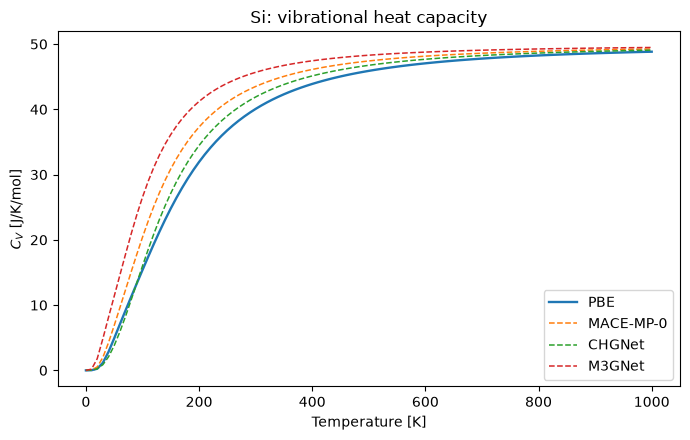

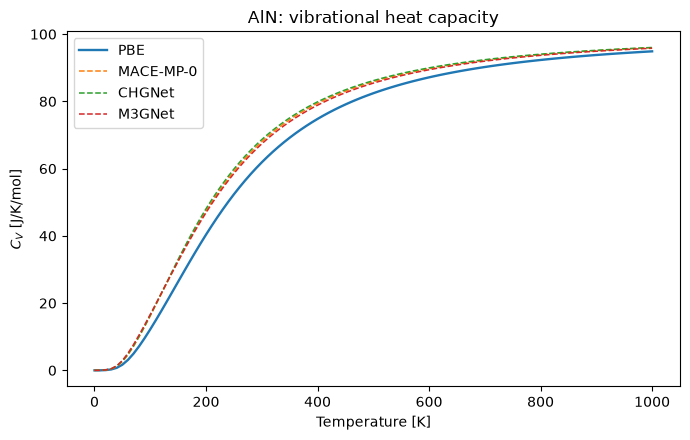

In [22]:
CURVE_MATERIALS = ["Si", "AlN"]

for material in CURVE_MATERIALS:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(
        np.asarray(pbe[material]["thermal"]["T"], dtype=float),
        np.asarray(pbe[material]["thermal"]["C_v"], dtype=float),
        linewidth=1.7,
        label="PBE",
    )

    for model in MODELS:
        r = results[model][material]

        ax.plot(
            np.asarray(r["thermal"]["T"], dtype=float),
            np.asarray(r["thermal"]["C_v"], dtype=float),
            linestyle="--",
            linewidth=1.1,
            label=MODEL_LABELS[model],
        )

    ax.set_xlabel("Temperature [K]")
    ax.set_ylabel("$C_V$ [J/K/mol]")
    ax.set_title(f"{material}: vibrational heat capacity")
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        FIGURES / f"heat_capacity_{material}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

## 10. PBEsol as a DFT-level baseline

The PBE–PBEsol difference gives a physically meaningful reference scale: it shows how
much the observables change even when both calculations are first-principles DFT but use
different exchange-correlation functionals.

The full paper reports that PBEsol generally contracts cells and hardens phonons
relative to PBE. The following table checks the same tendency on this reduced subset.

In [23]:
pbesol_rows = []

for material in MATERIALS:
    delta_omega_thz = (
        pbesol[material]["omega_max_THz"]
        - pbe[material]["omega_max_THz"]
    )

    pbesol_rows.append(
        {
            "material": material,
            "delta volume [A^3/atom]": (
                pbesol[material]["volume"] / pbesol[material]["n_atoms_unitcell"]
                - pbe[material]["volume"] / pbe[material]["n_atoms_unitcell"]
            ),
            "delta omega_max [THz]": delta_omega_thz,
            "delta omega_max [K]": delta_omega_thz * THZ_TO_K,
            "delta S [J/K/mol]": (
                pbesol[material]["thermal_300K"]["S"]
                - pbe[material]["thermal_300K"]["S"]
            ),
            "delta F [kJ/mol]": (
                pbesol[material]["thermal_300K"]["F"]
                - pbe[material]["thermal_300K"]["F"]
            ),
            "delta C_v [J/K/mol]": (
                pbesol[material]["thermal_300K"]["C_v"]
                - pbe[material]["thermal_300K"]["C_v"]
            ),
        }
    )

pbesol_table = pd.DataFrame(pbesol_rows).set_index("material")
display(pbesol_table.round(3))

,delta volume [A^3/atom],delta omega_max [THz],delta omega_max [K],delta S [J/K/mol],delta F [kJ/mol],delta C_v [J/K/mol]
material,,,,,,
Si,-0.364,0.180,8.626,0.360,-0.031,-0.172
SiC,-0.145,0.311,14.927,-0.130,0.251,-0.296
AlP,-0.388,0.228,10.935,0.219,0.012,-0.189
ZnS,-0.946,0.443,21.248,-1.640,0.639,-0.427
MgO,-0.260,0.235,11.273,-1.173,0.569,-0.559
NaCl,-1.087,0.244,11.720,-2.293,0.753,-0.207
AlN,-0.170,0.369,17.719,-0.486,0.577,-0.753
GaN,-0.410,0.610,29.285,-1.833,1.168,-1.263


In [24]:
pbesol_benchmark_comparison = pd.DataFrame(
    {
        "subset PBEsol vs PBE": [
            np.mean(np.abs(pbesol_table["delta omega_max [K]"])),
            thermal_mae.loc["PBEsol", "MAE S [J/K/mol]"],
            thermal_mae.loc["PBEsol", "MAE F [kJ/mol]"],
            thermal_mae.loc["PBEsol", "MAE C_v [J/K/mol]"],
        ],
        "Loew et al. full benchmark": [
            PAPER_MAE.loc["PBEsol", "omega_max [K]"],
            PAPER_MAE.loc["PBEsol", "S [J/K/mol]"],
            PAPER_MAE.loc["PBEsol", "F [kJ/mol]"],
            PAPER_MAE.loc["PBEsol", "C_v [J/K/mol]"],
        ],
    },
    index=[
        "omega_max [K]",
        "S [J/K/mol]",
        "F [kJ/mol]",
        "C_v [J/K/mol]",
    ],
)

display(pbesol_benchmark_comparison.round(2))

,subset PBEsol vs PBE,Loew et al. full benchmark
omega_max [K],15.72,33.0
S [J/K/mol],1.02,25.0
F [kJ/mol],0.50,10.0
C_v [J/K/mol],0.48,5.0


## 11. Runtime — descriptive only

The JSON files contain end-to-end runtime for each material. These values are useful as
implementation metadata but **not** as a controlled speed benchmark, because the three
models use different software stacks and potentially different execution backends.

In [25]:
runtime_table = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[model],
            "mean runtime [s]": np.mean(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
            "median runtime [s]": np.median(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
            "total runtime [s]": np.sum(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
        }
        for model in MODELS
    ]
).set_index("model")

display(runtime_table.round(2))

,mean runtime [s],median runtime [s],total runtime [s]
model,,,
MACE-MP-0,4.18,3.60,33.41
CHGNet,2.11,1.56,16.90
M3GNet,2.36,1.60,18.85


## 12. Data-driven discussion

The following cell builds a compact interpretation directly from the current JSON files.
This prevents the written discussion from silently becoming inconsistent with regenerated
results.

In [26]:
best_omega = omega_stats["MAE [K]"].idxmin()

bias_lines = []

for model in MODELS:
    label = MODEL_LABELS[model]
    bias = omega_stats.loc[label, "mean signed error [K]"]

    if abs(bias) < 1.0:
        tendency = "shows essentially no mean signed bias"
    elif bias < 0:
        tendency = "shows a mean softening"
    else:
        tendency = "shows a mean hardening"

    bias_lines.append(
        f"- **{label}** {tendency} of {bias:+.1f} K in omega_max."
    )

our_rank = " < ".join(
    omega_stats["MAE [K]"].sort_values().index
)

paper_rank = " < ".join(
    PAPER_MAE.loc[
        ["MACE-MP-0", "CHGNet", "M3GNet"],
        "omega_max [K]",
    ].sort_values().index
)

stability_lines = []

for model in MODELS:
    label = MODEL_LABELS[model]
    agreement = int(stability_summary.loc[label, "agreement"])

    stability_lines.append(
        f"- **{label}** agrees with PBE for "
        f"{agreement}/{len(MATERIALS)} stability classifications."
    )

discussion_lines = [
    "### Main observations from this eight-material subset",
    "",
    f"**Maximum frequency.** The lowest subset MAE is obtained by **{best_omega}**.",
    f"The subset ranking is **{our_rank}**, whereas the full-benchmark ranking "
    f"among these three models is **{paper_rank}**.",
    "",
    *bias_lines,
    "",
    "**Dynamical stability.**",
    "",
    *stability_lines,
    "",
    "These numbers should be interpreted as a **small case study**, not as an "
    "independent statistical reproduction of the approximately 10,000-material "
    "benchmark. Agreement in ranking or systematic bias is meaningful qualitative "
    "evidence; disagreement for one or two materials can reflect the deliberately "
    "narrow composition and crystal-structure distribution used here.",
]

display(Markdown("\n".join(discussion_lines)))

### Main observations from this eight-material subset

**Maximum frequency.** The lowest subset MAE is obtained by **MACE-MP-0**.
The subset ranking is **MACE-MP-0 < CHGNet < M3GNet**, whereas the full-benchmark ranking among these three models is **MACE-MP-0 < CHGNet < M3GNet**.

- **MACE-MP-0** shows a mean softening of -112.7 K in omega_max.
- **CHGNet** shows a mean softening of -128.1 K in omega_max.
- **M3GNet** shows a mean softening of -131.3 K in omega_max.

**Dynamical stability.**

- **MACE-MP-0** agrees with PBE for 8/8 stability classifications.
- **CHGNet** agrees with PBE for 8/8 stability classifications.
- **M3GNet** agrees with PBE for 8/8 stability classifications.

These numbers should be interpreted as a **small case study**, not as an independent statistical reproduction of the approximately 10,000-material benchmark. Agreement in ranking or systematic bias is meaningful qualitative evidence; disagreement for one or two materials can reflect the deliberately narrow composition and crystal-structure distribution used here.

## 13. Conclusions and limitations

This project tests whether three pretrained universal ML interatomic potentials can
recover harmonic vibrational properties that depend on the **curvature** of the
potential-energy surface rather than only the energies and forces used in training.

The methodology was kept aligned with Loew *et al.* wherever possible:

- PBE Alexandria structures are used as initial geometries and the main DFT reference;
- MLIP relaxations preserve crystal symmetry;
- DFT reference supercell and primitive matrices are reused;
- finite displacements are 0.01 Å and residual force drift is removed;
- \(\omega_{\max}\) and dynamical stability are evaluated at commensurate q-points;
- thermodynamic quantities are evaluated on a 20×20×20 mesh;
- dispersion overlays use the same PBE-derived q-path;
- NAC is disabled consistently.

### Limitations

The strongest limitation is sample size: **8 simple crystals are not representative of
the approximately 10,000 compounds in the published benchmark**.

The project also omits the phonon DOS and average sound-velocity metrics from the
original paper. Runtime values are not a controlled performance benchmark.

The purpose of this reduced study is therefore not to reproduce the paper's global
statistics exactly, but to verify its methodology on concrete materials and determine
whether the same qualitative trends appear for MACE-MP-0, CHGNet, and M3GNet.

## 14. References

1. A. Loew, D. Sun, H.-C. Wang, S. Botti, M. A. L. Marques,  
   **Universal machine learning interatomic potentials are ready for phonons**,  
   *npj Computational Materials* **11**, 178 (2025).  
   DOI: https://doi.org/10.1038/s41524-025-01650-1

2. A. Togo, I. Tanaka,  
   **First principles phonon calculations in materials science**,  
   *Scripta Materialia* **108**, 1–5 (2015).  
   https://phonopy.github.io/phonopy/

3. I. Batatia *et al.*,  
   **MACE: Higher Order Equivariant Message Passing Neural Networks for Fast and Accurate Force Fields**,  
   NeurIPS (2022).

4. B. Deng *et al.*,  
   **CHGNet as a pretrained universal neural network potential for charge-informed atomistic modelling**,  
   *Nature Machine Intelligence* **5**, 1031–1041 (2023).

5. C. Chen, S. P. Ong,  
   **A universal graph deep learning interatomic potential for the periodic table**,  
   *Nature Computational Science* **2**, 718–728 (2022).

6. Alexandria phonon benchmark: https://alexandria.icams.rub.de/